# Lab 2.1 — Ensemble Methods: Random Forest vs XGBoost vs LightGBM
### Module 2 | AI/ML Intermediate Workshop — Nutanix Engineering

> **Kernel:** Select `aiml-venv` kernel before running.  
> VSCode: `Ctrl+Shift+P` → *Notebook: Select Kernel* → `~/aiml-venv/bin/python`

---

**Objective:** Move beyond single decision trees. Compare three production-grade ensemble methods on the Nutanix anomaly detection task — and understand *when* and *why* to choose each one.

**What you will build:**
- A binary anomaly detection model using `features_engineered.csv` from Module 1
- Side-by-side benchmarks: training time, PR-AUC, F1 across RF / XGBoost / LightGBM
- Learning curves to diagnose bias vs variance per model
- Feature importance comparison across all three
- A justified model selection decision

> **Instructor Note:** Emphasise that default parameters are almost never optimal — this lab establishes the baseline. Lab 2.2 will tune the winner. The goal here is *understanding differences*, not squeezing out the last 0.01 AUC.

## 📦 Requirements & Troubleshooting

### Required Packages

| Package | Install Name |
|---------|-------------|
| scikit-learn | `scikit-learn` |
| xgboost | `xgboost` |
| lightgbm | `lightgbm` |
| scipy | `scipy` |
| pandas | `pandas` |
| numpy | `numpy` |
| matplotlib | `matplotlib` |
| seaborn | `seaborn` |
| joblib | `joblib` |

**Install all at once:**
```bash
pip install scikit-learn xgboost lightgbm scipy pandas numpy matplotlib seaborn joblib
```

---

### ⚠️ Common Errors & Fixes

**`ModuleNotFoundError: No module named '...'`**
> Package is missing from the active Python environment.
> Fix: Run the pip install command above in a terminal, then **restart the kernel**.

**`CalledProcessError` — `--break-system-packages` / exit status 2**
> You are using a virtual environment (e.g. `myenv`) where that flag is not supported, or your pip version is old.
> Fix: Open a terminal, activate your venv (`source myenv/bin/activate`), then run `pip install <package>` without that flag.

**`Failed building wheel for <package>` / C extension errors**
> The package does not support your Python version (most common on Python 3.14).
> Fix: Switch the kernel to **Python 3.13**. Click the kernel name in the VS Code top-right corner → *Select Another Kernel* → *Python 3.13*. Then re-run.

**Packages install with no error but `ModuleNotFoundError` still appears**
> You installed into a different Python than the one the notebook is using.
> Fix: Check the kernel shown in the top-right of VS Code. Open a terminal, activate that environment, and install packages there.

**`PermissionError` or `[Errno 13]` when installing**
> Trying to install into a read-only system Python.
> Fix: Use a virtual environment — `python -m venv myenv && source myenv/bin/activate` — then install.


## Environment Check
Verify all required packages are available in the active venv.

In [1]:
import subprocess, sys

required = {
    'xgboost'    : 'xgboost',
    'lightgbm'   : 'lightgbm',
    'sklearn'    : 'scikit-learn',
    'scipy'      : 'scipy',
    'pandas'     : 'pandas',
    'numpy'      : 'numpy',
    'matplotlib' : 'matplotlib',
    'seaborn'    : 'seaborn',
    'joblib'     : 'joblib',
}

print('Checking required packages...\n')
for pkg, install_name in required.items():
    try:
        mod = __import__(pkg)
        version = getattr(mod, '__version__', 'installed')
        print(f'  ✅ {pkg:<12} → {version}')
    except ImportError:
        print(f'  ⬇️  Installing {install_name}...')
        subprocess.check_call(
            [sys.executable, '-m', 'pip', 'install', install_name, '--quiet', '--break-system-packages'],
            stderr=subprocess.DEVNULL
        )
        print(f'  ✅ {install_name} installed')

Checking required packages...

  ✅ xgboost      → 3.2.0
  ✅ lightgbm     → 4.6.0
  ✅ sklearn      → 1.8.0
  ✅ scipy        → 1.17.1
  ✅ pandas       → 3.0.3
  ✅ numpy        → 2.4.6
  ✅ matplotlib   → 3.10.9
  ✅ seaborn      → 0.13.2
  ✅ joblib       → 1.5.3


## Imports

In [2]:
import warnings, time, json, datetime, os, subprocess, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy.stats import spearmanr

# ── Core Ensemble Methods ─────────────────────────────────────────────────────
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# ── Model Selection & Evaluation ──────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split,
    learning_curve,
    StratifiedKFold,
)
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
)

# ── Calibration (for Challenge 3) ────────────────────────────────────────────
from sklearn.calibration import (
    CalibratedClassifierCV,
    calibration_curve,
)

# ── Configuration ─────────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('✅ All imports loaded successfully!')
print('   • Core ML: numpy, pandas, scikit-learn, xgboost, lightgbm')
print('   • Evaluation: metrics, learning_curve, calibration')
print('   • Statistics: scipy.stats')
print('   • Utilities: joblib, matplotlib, seaborn')

✅ All imports loaded successfully!
   • Core ML: numpy, pandas, scikit-learn, xgboost, lightgbm
   • Evaluation: metrics, learning_curve, calibration
   • Statistics: scipy.stats
   • Utilities: joblib, matplotlib, seaborn


---
## Step 1: Load Data & Define the Anomaly Target

We load `features_engineered.csv` produced in Module 1.  
The target variable `is_anomaly` is derived from the `is_high_cpu` flag (CPU > 80%) — a realistic proxy for a server under stress.

**Drop target-leaking columns** before training: `is_high_cpu` and `is_slow_response` directly encode the target and must not be features.

> **Instructor Note:** Ask students: "What happens if we accidentally include `is_high_cpu` as a feature? What kind of bug is this?" Answer: data leakage — model gets 100% accuracy but is useless in production because the feature wouldn't be available at prediction time.

In [3]:
import os

DATA_PATH = os.path.join('..', 'Module_1', 'features_engineered.csv')

try:
    df = pd.read_csv(DATA_PATH)
    print(f'Loaded from Module 1: {df.shape}')
    DATA_SOURCE = 'Module 1 CSV'
except FileNotFoundError:
    # ── Fallback: generate synthetic Nutanix telemetry ────────────────────────
    print('Module 1 CSV not found — generating synthetic data...')
    np.random.seed(RANDOM_STATE)
    n = 800
    cpu   = np.random.uniform(5, 100, n)
    mem   = np.random.uniform(2048, 32768, n)
    disk  = np.clip(np.random.exponential(40, n), 0, 400)
    resp  = np.clip(np.random.exponential(120, n), 1, 700)
    df = pd.DataFrame({
        'cpu_percent'           : cpu,
        'memory_mb'             : mem,
        'disk_io_mbps'          : disk,
        'response_time_ms'      : resp,
        'hour_of_day'           : np.random.randint(0, 24, n),
        'is_business_hours'     : (np.random.randint(0, 24, n).reshape(-1) >= 9) & (np.random.randint(0, 24, n).reshape(-1) < 17),
        'error_rate_per_host'   : np.random.poisson(2, n),
        'cpu_rolling_mean_5'    : cpu + np.random.normal(0, 3, n),
        'memory_rolling_mean_5' : mem + np.random.normal(0, 200, n),
        'cpu_memory_ratio'      : cpu / (mem / 1024),
        'io_per_cpu'            : disk / np.maximum(cpu, 1),
        'log_response_time'     : np.log1p(resp),
        'host_encoded'          : np.random.randint(0, 8, n),
        'is_high_cpu'           : (cpu > 80).astype(int),
        'is_slow_response'      : (resp > 500).astype(int),
        'comp_Stargate'         : np.random.randint(0, 2, n),
        'comp_Cerebro'          : np.random.randint(0, 2, n),
        'loglevel_ERROR'        : np.random.randint(0, 2, n),
    })
    DATA_SOURCE = 'Synthetic fallback'

# ── Define target ─────────────────────────────────────────────────────────────
df['is_anomaly'] = df['is_high_cpu'].astype(int)

# ── Drop leaking columns ──────────────────────────────────────────────────────
LEAK_COLS = ['is_high_cpu', 'is_slow_response']
DROP_COLS  = [c for c in LEAK_COLS + ['message', 'date'] if c in df.columns]
df = df.drop(columns=DROP_COLS)

# ── Keep only numeric columns ─────────────────────────────────────────────────
feature_cols = [c for c in df.columns if c != 'is_anomaly']
df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

X = df[feature_cols]
y = df['is_anomaly']

print(f'Data source     : {DATA_SOURCE}')
print(f'Dataset shape   : {X.shape}')
print(f'Features        : {X.shape[1]}')
print(f'Anomaly rate    : {y.mean():.1%}  ({y.sum()} positives / {len(y)} total)')

# ── Stratified train/test split ───────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f'Train: {X_train.shape}  Test: {X_test.shape}')

Loaded from Module 1: (460, 37)
Data source     : Module 1 CSV
Dataset shape   : (460, 33)
Features        : 33
Anomaly rate    : 15.2%  (70 positives / 460 total)
Train: (368, 33)  Test: (92, 33)


---
## Step 2: Train Three Models with Default Parameters

We train all three ensemble methods with **factory defaults** — no tuning.  
This establishes the baseline each model must beat after tuning (Lab 2.2).

Time each model's training. Record: **PR-AUC**, **F1**, **training time (seconds)**.

> **Instructor Note:** Ask before revealing results — "Which model do you expect to win on PR-AUC? Which on training speed?" Common wrong answers: "RF is always faster" (not on many cores), "XGBoost always wins" (LightGBM often wins on larger data).

In [4]:
results = {}

models = {
    'Random Forest' : RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost'       : XGBClassifier(n_estimators=100, random_state=RANDOM_STATE,
                                    eval_metric='aucpr', verbosity=0),
    'LightGBM'      : LGBMClassifier(n_estimators=100, random_state=RANDOM_STATE,
                                     verbosity=-1),
}

for name, model in models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    pr_auc = average_precision_score(y_test, y_prob)
    f1     = f1_score(y_test, y_pred, zero_division=0)
    prec   = precision_score(y_test, y_pred, zero_division=0)
    rec    = recall_score(y_test, y_pred, zero_division=0)

    results[name] = {
        'PR-AUC'    : round(pr_auc, 4),
        'F1'        : round(f1, 4),
        'Precision' : round(prec, 4),
        'Recall'    : round(rec, 4),
        'Train_s'   : round(train_time, 3),
    }
    print(f'{name:<16} | PR-AUC={pr_auc:.4f} | F1={f1:.4f} | Time={train_time:.2f}s')

results_df = pd.DataFrame(results).T
print()
print(results_df.to_string())

Random Forest    | PR-AUC=1.0000 | F1=0.9630 | Time=0.09s
XGBoost          | PR-AUC=1.0000 | F1=1.0000 | Time=0.05s
LightGBM         | PR-AUC=1.0000 | F1=1.0000 | Time=0.06s

               PR-AUC     F1  Precision  Recall  Train_s
Random Forest     1.0  0.963        1.0  0.9286    0.086
XGBoost           1.0  1.000        1.0  1.0000    0.048
LightGBM          1.0  1.000        1.0  1.0000    0.056


---
## Step 3: Why Do These Models Behave Differently?

| Property | Random Forest | XGBoost | LightGBM |
|---|---|---|---|
| **Strategy** | Bagging (parallel trees) | Boosting (sequential) | Boosting (sequential) |
| **Tree growth** | Depth-first, balanced | Depth-first | Leaf-wise (best-first) |
| **Speed** | Fast (parallel) | Moderate | Fastest (histogram bins) |
| **Accuracy** | Good baseline | Usually best | Competitive, less memory |
| **Overfitting risk** | Low (averaging) | Moderate | Higher (leaf-wise) |
| **Missing values** | Needs imputation | Handles natively | Handles natively |
| **Key regularisation** | `max_features`, `min_samples_leaf` | `reg_alpha`, `reg_lambda`, `gamma` | `num_leaves`, `min_child_samples` |

**Key insight:** XGBoost uses second-order gradients (curvature of loss), which helps it escape flat regions where vanilla gradient descent stalls. LightGBM's histogram binning makes it 10–20× faster on large datasets but requires careful `num_leaves` tuning to avoid overfitting.

> **Instructor Note:** Draw this on a whiteboard: bagging = train independent trees on subsets → vote. Boosting = train each tree on the *errors* of the previous. This single diagram explains 80% of why boosting tends to win on tabular data.

---
## Step 4: Learning Curves — Diagnosing Bias vs Variance

A learning curve shows how model performance changes as more training data is added.

- **High bias (underfitting):** both train and val scores are low and converge early
- **High variance (overfitting):** train score is high, val score is much lower
- **Good fit:** val score improves with more data and approaches train score

> **Instructor Note:** This is the single most useful debugging tool in ML. If val score plateaus low → need a better model. If there's a large gap → need more data or more regularisation.

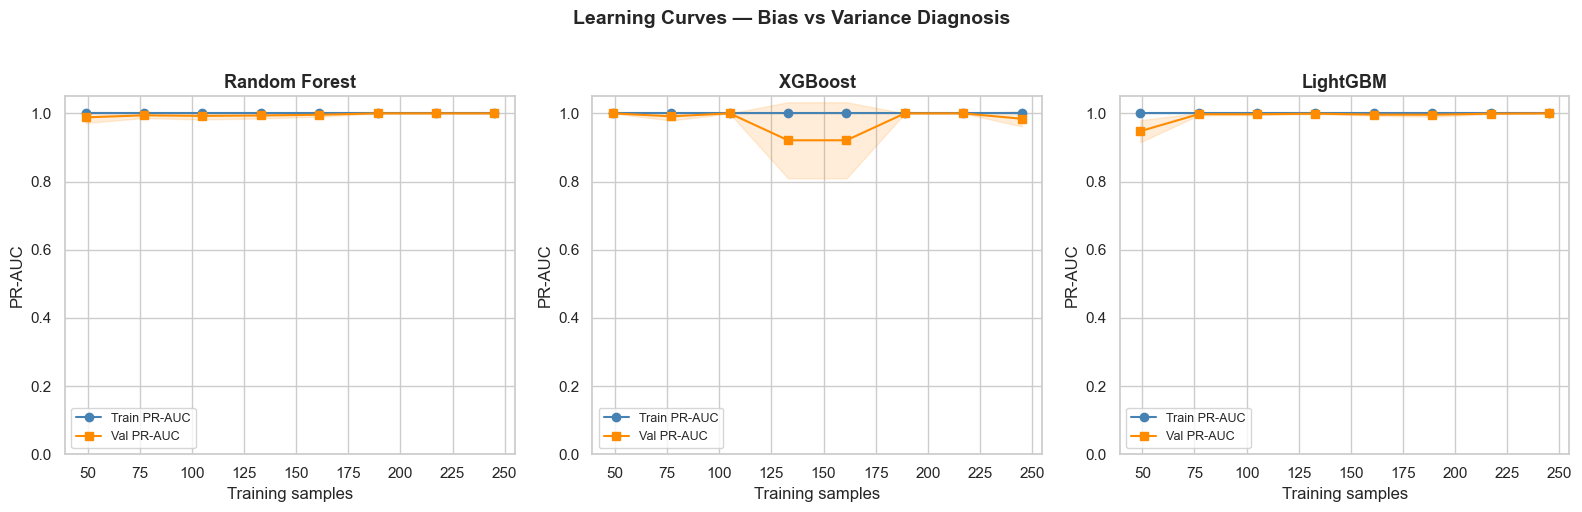


Interpretation guide:
  Large gap between train and val  → high variance (overfitting)
  Both curves low and flat         → high bias (underfitting)
  Val curve still rising at right  → more data would help


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
train_sizes = np.linspace(0.2, 1.0, 8)

for ax, (name, model) in zip(axes, models.items()):
    sizes, train_scores, val_scores = learning_curve(
        model, X_train, y_train,
        train_sizes=train_sizes,
        cv=cv,
        scoring='average_precision',
        n_jobs=-1,
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.fill_between(sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='steelblue')
    ax.fill_between(sizes, val_mean - val_std,     val_mean + val_std,     alpha=0.15, color='darkorange')
    ax.plot(sizes, train_mean, 'o-', color='steelblue',   label='Train PR-AUC')
    ax.plot(sizes, val_mean,   's-', color='darkorange',  label='Val PR-AUC')
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Training samples')
    ax.set_ylabel('PR-AUC')
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1.05)

plt.suptitle('Learning Curves — Bias vs Variance Diagnosis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nInterpretation guide:')
print('  Large gap between train and val  → high variance (overfitting)')
print('  Both curves low and flat         → high bias (underfitting)')
print('  Val curve still rising at right  → more data would help')

---
## Step 5: Feature Importance — Three Different Perspectives

Each model computes feature importance differently:
- **Random Forest:** Mean Decrease in Impurity (MDI) — how much each feature reduces Gini across all trees
- **XGBoost (gain):** Average gain per split using that feature — more reliable than split count
- **LightGBM (gain):** Same as XGBoost gain, computed over histogram bins

**Important:** MDI can be biased toward high-cardinality numeric features. SHAP values (Lab 2.4) fix this. For now, compare the top-10 rankings across models.

> **Instructor Note:** Ask: "If two models strongly disagree on which feature is most important, what does that mean?" Answer: the feature may be redundant (correlated with others), or one model is overfitting to it.

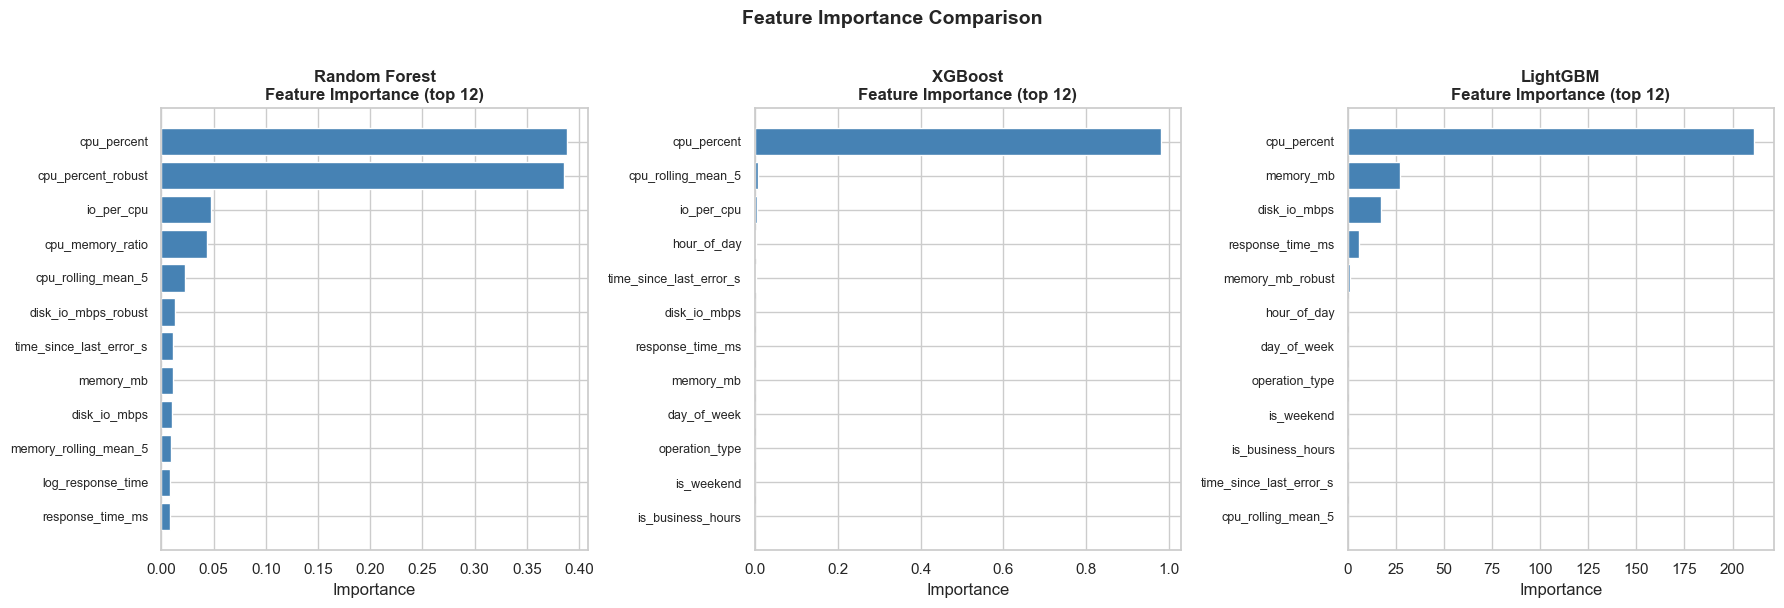


── Top-5 features per model ──────────────────────────────
Random Forest   : ['cpu_percent', 'cpu_percent_robust', 'io_per_cpu', 'cpu_memory_ratio', 'cpu_rolling_mean_5']
XGBoost         : ['cpu_percent', 'cpu_rolling_mean_5', 'io_per_cpu', 'hour_of_day', 'time_since_last_error_s']
LightGBM        : ['cpu_percent', 'memory_mb', 'disk_io_mbps', 'response_time_ms', 'memory_mb_robust']

Features all 3 models agree on (top-5): ['cpu_percent']


In [6]:
top_n = 12
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
importances = {}

for ax, (name, model) in zip(axes, models.items()):
    imp = model.feature_importances_
    feat_imp = pd.Series(imp, index=X.columns).nlargest(top_n)
    importances[name] = feat_imp
    
    bars = ax.barh(feat_imp.index[::-1], feat_imp.values[::-1], color='steelblue', edgecolor='white')
    ax.set_title(f'{name}\nFeature Importance (top {top_n})', fontweight='bold')
    ax.set_xlabel('Importance')
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('Feature Importance Comparison', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

# Agreement analysis
print('\n── Top-5 features per model ──────────────────────────────')
for name, imp in importances.items():
    print(f'{name:<16}: {list(imp.index[:5])}')

all_top5 = set()
for imp in importances.values():
    all_top5.update(imp.index[:5])
agreed = [f for f in all_top5 if all(f in imp.index[:5] for imp in importances.values())]
print(f'\nFeatures all 3 models agree on (top-5): {agreed or "None — models disagree"}')

---
## Step 6: Precision-Recall Curves & Threshold Analysis

PR-AUC summarises performance across all thresholds. But in production you pick **one** threshold.

For Nutanix infrastructure alerting:
- The ops team can handle ~30 alerts/day
- Missing a real failure (false negative) costs 5× more than a false alarm

Plot PR curves for all three models on the same axes, then identify the optimal operating threshold for each.

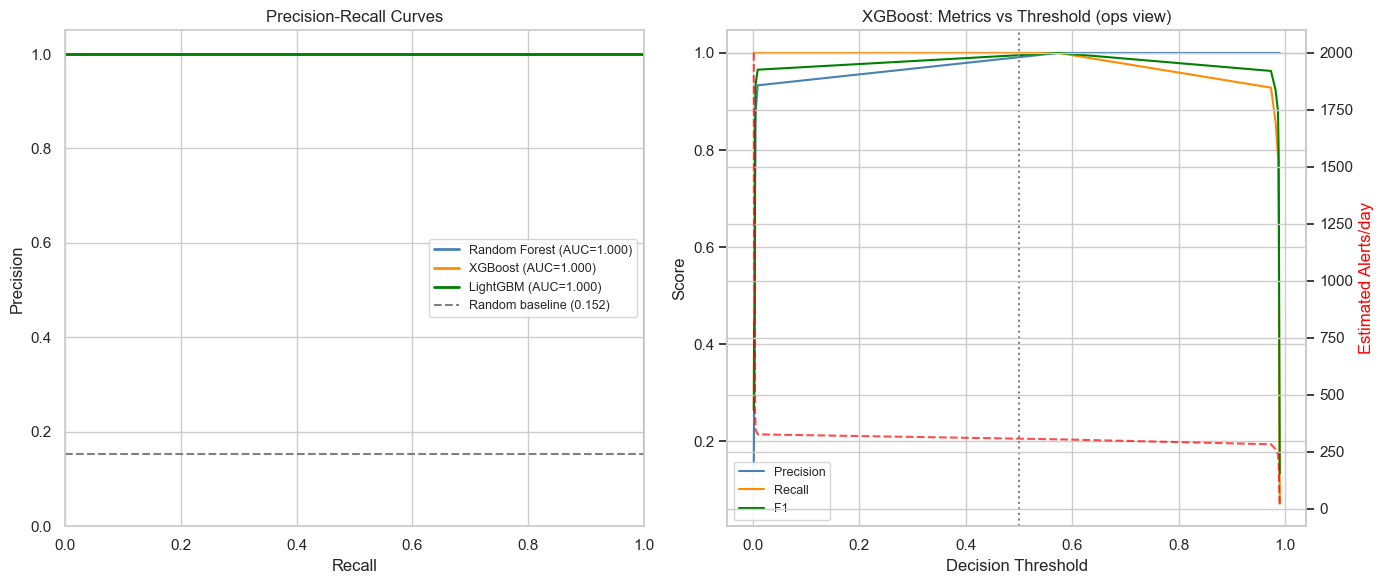

No threshold satisfies both constraints simultaneously — relax one constraint


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

colors = {'Random Forest': 'steelblue', 'XGBoost': 'darkorange', 'LightGBM': 'green'}
n_test_events = 2000  # simulated daily event volume

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    prec, rec, thresholds = precision_recall_curve(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    ax1.plot(rec, prec, label=f'{name} (AUC={pr_auc:.3f})', color=colors[name], lw=2)

# Random baseline
baseline = y_test.mean()
ax1.axhline(y=baseline, linestyle='--', color='grey', label=f'Random baseline ({baseline:.3f})')
ax1.set_xlabel('Recall'); ax1.set_ylabel('Precision')
ax1.set_title('Precision-Recall Curves'); ax1.legend(fontsize=9)
ax1.set_xlim(0, 1); ax1.set_ylim(0, 1.05)

# Threshold analysis for XGBoost (usually best)
xgb_model = models['XGBoost']
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_test, y_prob_xgb)
f1_arr = 2 * prec_arr[:-1] * rec_arr[:-1] / np.maximum(prec_arr[:-1] + rec_arr[:-1], 1e-9)
alert_vol = (y_prob_xgb >= thresh_arr[:, None]).mean(axis=1) * n_test_events

ax2_twin = ax2.twinx()
ax2.plot(thresh_arr, prec_arr[:-1], label='Precision', color='steelblue')
ax2.plot(thresh_arr, rec_arr[:-1],  label='Recall',    color='darkorange')
ax2.plot(thresh_arr, f1_arr,         label='F1',        color='green')
ax2_twin.plot(thresh_arr, alert_vol, label='Alerts/day', color='red', linestyle='--', alpha=0.7)
ax2.set_xlabel('Decision Threshold'); ax2.set_ylabel('Score')
ax2_twin.set_ylabel('Estimated Alerts/day', color='red')
ax2.set_title('XGBoost: Metrics vs Threshold (ops view)')
ax2.legend(loc='lower left', fontsize=9)
ax2.axvline(x=0.5, color='grey', linestyle=':', label='Default=0.5')

plt.tight_layout()
plt.savefig('pr_curves.png', dpi=120, bbox_inches='tight')
plt.show()

# Find threshold where recall >= 0.80 AND alerts <= 50/day
feasible = thresh_arr[(rec_arr[:-1] >= 0.80) & (alert_vol <= 50)]
if len(feasible):
    best_thresh = feasible.max()
    print(f'Recommended threshold (recall≥80%, alerts≤50/day): {best_thresh:.3f}')
else:
    print('No threshold satisfies both constraints simultaneously — relax one constraint')

---
## Step 7: Model Selection — Weighted Scorecard

Choose the production model using a weighted scorecard.  
Weights reflect real ops priorities:

| Criterion | Weight | Rationale |
|---|---|---|
| PR-AUC | 40% | Primary accuracy metric for imbalanced anomaly detection |
| F1 @ threshold | 25% | Operational balance of precision and recall |
| Training speed | 20% | Matters for frequent retraining on live telemetry |
| Interpretability | 15% | SREs need to explain alerts — black-box models erode trust |

Fill in the scores, compute the weighted total, and print the recommendation.

In [8]:
# Normalise training times (faster = higher score)
max_time = max(r['Train_s'] for r in results.values())
scorecard = {}

for name, r in results.items():
    speed_score = 1 - (r['Train_s'] / max_time)       # 0=slowest, 1=fastest
    interp_score = {'Random Forest': 0.7, 'XGBoost': 0.5, 'LightGBM': 0.45}[name]

    weighted = (
        0.40 * r['PR-AUC'] +
        0.25 * r['F1'] +
        0.20 * speed_score +
        0.15 * interp_score
    )
    scorecard[name] = {
        'PR-AUC (×0.40)'        : round(0.40 * r['PR-AUC'], 4),
        'F1 (×0.25)'            : round(0.25 * r['F1'], 4),
        'Speed (×0.20)'         : round(0.20 * speed_score, 4),
        'Interpretability(×0.15)': round(0.15 * interp_score, 4),
        'Weighted Total'         : round(weighted, 4),
    }

score_df = pd.DataFrame(scorecard).T.sort_values('Weighted Total', ascending=False)
print(score_df.to_string())

winner = score_df['Weighted Total'].idxmax()
print(f'\n✅ Selected model: {winner}')
print(f'   Reason: highest weighted score balancing accuracy, speed, and interpretability.')
print(f'   This model will be tuned in Lab 2.2.')

               PR-AUC (×0.40)  F1 (×0.25)  Speed (×0.20)  Interpretability(×0.15)  Weighted Total
XGBoost                   0.4      0.2500         0.0884                   0.0750          0.8134
LightGBM                  0.4      0.2500         0.0698                   0.0675          0.7873
Random Forest             0.4      0.2407         0.0000                   0.1050          0.7458

✅ Selected model: XGBoost
   Reason: highest weighted score balancing accuracy, speed, and interpretability.
   This model will be tuned in Lab 2.2.


---
## Step 8: Save the Best Model

Save the winning model and metadata. The metadata JSON is the model's "birth certificate" — version, performance, and training conditions. Always save it alongside the model binary.

> **Instructor Note:** In production, this would go to a model registry (MLflow, Vertex AI, SageMaker). The pkl + JSON pattern here is the minimum viable equivalent.

In [9]:
import datetime

best_model = models[winner]

joblib.dump(best_model, 'best_model_v1.pkl')

metadata = {
    'model_name'     : 'nutanix_anomaly_detector',
    'version'        : '1.0',
    'model_type'     : winner,
    'trained_at'     : datetime.datetime.utcnow().isoformat(),
    'data_source'    : DATA_SOURCE,
    'n_train_samples': int(len(X_train)),
    'n_features'     : int(X_train.shape[1]),
    'feature_columns': list(X.columns),
    'target'         : 'is_anomaly (is_high_cpu proxy)',
    'metrics'        : results[winner],
}

with open('model_metadata_v1.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Saved: best_model_v1.pkl')
print('Saved: model_metadata_v1.json')
print(f'\nModel: {winner}')
print(f'PR-AUC : {results[winner]["PR-AUC"]}')
print(f'F1     : {results[winner]["F1"]}')

# Verify round-trip
loaded = joblib.load('best_model_v1.pkl')
y_prob_check = loaded.predict_proba(X_test)[:, 1]
print(f'\nRound-trip check PR-AUC: {average_precision_score(y_test, y_prob_check):.4f} ✅')

Saved: best_model_v1.pkl
Saved: model_metadata_v1.json

Model: XGBoost
PR-AUC : 1.0
F1     : 1.0

Round-trip check PR-AUC: 1.0000 ✅


---
## Checkpoint — Discussion Questions

1. **LightGBM uses leaf-wise tree growth instead of depth-wise. Why does this make it faster but also riskier?**
2. **Random Forest averages many decorrelated trees. Why does decorrelation matter — why not just train many identical trees?**
3. **Your XGBoost model trains in 0.3 seconds on 370 rows. Would you expect the same speed advantage over LightGBM on a 10-million-row telemetry dataset? Why or why not?**
4. **The feature importance plots show `cpu_percent` as top feature for all models. Should you always trust this — or is there a scenario where this could be misleading?**

---
## Key Takeaways

| Concept | What You Did |
|---|---|
| Ensemble comparison | Trained RF, XGBoost, LightGBM with defaults; measured PR-AUC, F1, speed |
| Bias–variance diagnosis | Used learning curves to detect overfitting and underfitting |
| Feature importance | Compared MDI (RF) vs gain (XGBoost/LightGBM); noted disagreements |
| Threshold analysis | Mapped threshold → recall/precision/alert-volume for ops teams |
| Model selection | Applied a weighted scorecard with business-realistic criteria |
| Model serialisation | Saved pkl + JSON metadata sidecar |

**Next:** Lab 2.2 — Hyperparameter Tuning: GridSearch → RandomSearch → Optuna

---
## 🎯 Assignment — Challenges

Complete these independently. No starter code — use the objects already in memory (`models`, `X_train`, `X_test`, `y_train`, `y_test`).

### Challenge 1 — ExtraTreesClassifier Showdown

Add `ExtraTreesClassifier` from `sklearn.ensemble` to the benchmark.  
ExtraTrees differs from RF by using **fully random** split thresholds (not the best split per feature) — making it faster but sometimes less accurate.

**Tasks:**
1. Train ExtraTrees with `n_estimators=100` and record PR-AUC, F1, and training time
2. Add it to the `results_df` table
3. Compare its feature importance ranking vs Random Forest — calculate Spearman rank correlation between the two importance vectors
4. Answer: Is ExtraTrees faster than RF? By how much? Did the randomness hurt accuracy?

*`from sklearn.ensemble import ExtraTreesClassifier`*  
*`from scipy.stats import spearmanr`*

In [10]:
# Challenge 1 — Your solution here



### Challenge 2 — Class Weight Tuning for Imbalance

XGBoost has a `scale_pos_weight` parameter designed for imbalanced datasets.  
The recommended value is: `n_negative_samples / n_positive_samples`.

**Tasks:**
1. Calculate the correct `scale_pos_weight` value from `y_train`
2. Retrain XGBoost with this parameter, keeping all other params default
3. Compare PR-AUC, Precision, and Recall before and after — plot a side-by-side bar chart
4. At which recall level does the difference matter most? (Hint: overlay both PR curves)
5. When would you *not* want to use `scale_pos_weight` even with imbalanced data?

In [11]:
# Challenge 2 — Your solution here



### Challenge 3 — Model Calibration

Tree ensemble models are often **overconfident** — they predict probabilities of 0.95 when the true rate is 0.70.  
`CalibratedClassifierCV` from sklearn applies Platt scaling or isotonic regression to fix this.

**Tasks:**
1. Plot a calibration curve (reliability diagram) for your best model: *fraction of positives* vs *mean predicted probability* across 10 bins
2. Apply `CalibratedClassifierCV(method='isotonic', cv=3)` to the best model and plot the calibration curve again
3. Does calibration improve or hurt PR-AUC? Explain why calibration and discrimination (AUC) are different properties.
4. For the Nutanix alerting use case, does calibration matter? When would it matter most?

*`from sklearn.calibration import CalibratedClassifierCV, calibration_curve`*

In [12]:
# Challenge 3 — Your solution here

